## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("mortgage_covenant_data.csv")
df.to_csv("hennepin_analysis.csv", index=False)

print("File converted successfully")

File converted successfully


## Perform EDA

In [3]:
df.shape

(100931, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [5]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['activity_year', 'census_tract', 'derived_race', 'action_taken',
       'loan_amount', 'property_value', 'income', 'interest_rate',
       'tract_minority_population_percent', 'tract_to_msa_income_percentage',
       'denial_reason-1', 'covenant_count', 'was_approved',
       'covenant_density'],
      dtype='object')


In [6]:
df.head(10)

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
5,2023,2.716307e+10,Race Not Available,6,185000.0,245000.0,NaN,6.250,20.25,152.30,10,0.0,False,NaN
6,2023,2.712303e+10,Race Not Available,6,235000.0,245000.0,NaN,6.750,84.32,39.16,10,0.0,False,NaN
7,2023,2.708595e+10,Race Not Available,6,225000.0,225000.0,NaN,6.250,9.68,115.40,10,0.0,False,NaN
8,2023,2.700305e+10,Race Not Available,6,315000.0,325000.0,NaN,7.125,18.86,86.27,10,0.0,False,NaN
9,2023,2.713700e+10,Race Not Available,6,195000.0,235000.0,NaN,6.625,18.53,69.66,10,0.0,False,NaN


In [7]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


,0
activity_year,0
census_tract,1016
derived_race,0
action_taken,0
loan_amount,0
property_value,17440
income,12731
interest_rate,22806
tract_minority_population_percent,0
tract_to_msa_income_percentage,0


In [8]:
print("\nSummary statistics:")
df.describe()


Summary statistics:


,activity_year,census_tract,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count
count,100931.0,9.991500e+04,100931.000000,1.009310e+05,8.349100e+04,8.820000e+04,78125.000000,100931.000000,100931.000000,100931.000000,100931.000000
mean,2023.0,2.708025e+10,2.309528,3.110060e+05,3.987726e+05,1.489660e+02,6.575084,22.874029,101.813583,48.624763,17.408101
std,0.0,5.254319e+07,1.950185,7.617088e+05,1.197102e+06,5.568826e+03,1.273054,17.292952,32.381060,203.617075,84.973673
min,2023.0,2.700177e+10,1.000000,5.000000e+03,5.000000e+03,-3.415700e+04,0.000000,0.000000,0.000000,1.000000,0.000000
25%,2023.0,2.703706e+10,1.000000,1.750000e+05,2.350000e+05,6.700000e+01,6.125000,10.140000,82.070000,10.000000,0.000000
50%,2023.0,2.705311e+10,1.000000,2.650000e+05,3.250000e+05,9.600000e+01,6.625000,18.640000,99.060000,10.000000,0.000000
75%,2023.0,2.712304e+10,4.000000,3.650000e+05,4.350000e+05,1.460000e+02,7.125000,29.710000,119.950000,10.000000,0.000000
max,2023.0,2.717397e+10,8.000000,5.700500e+07,1.113250e+08,1.651000e+06,15.500000,95.630000,240.430000,1111.000000,965.000000


In [9]:
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 791


In [10]:
df['activity_year'].value_counts()

,count
activity_year,
2023,100931


In [11]:
df['census_tract'].value_counts()

,count
census_tract,
2.705303e+10,606
2.716307e+10,580
2.705303e+10,432
2.705303e+10,420
2.717110e+10,384
...,...
2.712304e+10,4
2.712303e+10,3
2.713700e+10,2


In [12]:
df['derived_race'].value_counts()

,count
derived_race,
White,63627
Race Not Available,22811
Asian,5905
Black or African American,5199
Joint,2427
American Indian or Alaska Native,709
2 or more minority races,135
Native Hawaiian or Other Pacific Islander,113
Free Form Text Only,5


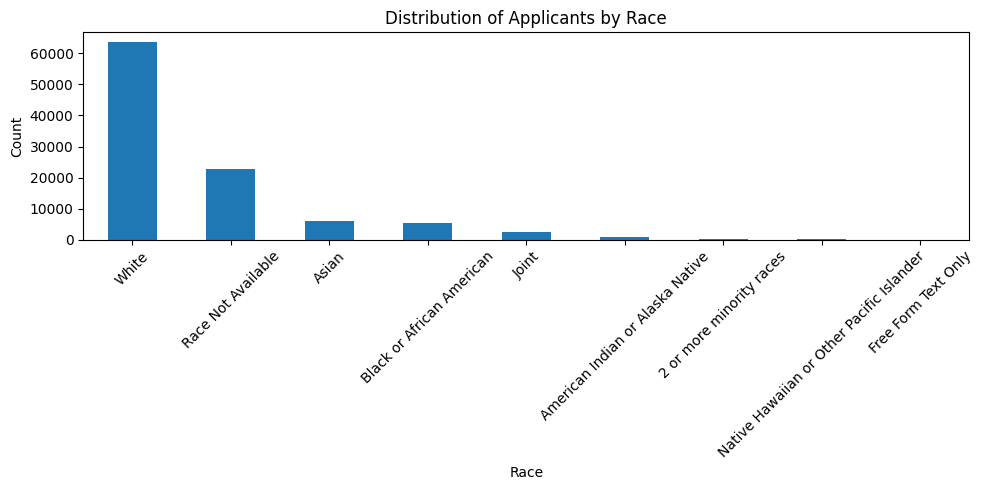

In [13]:
plt.figure(figsize=(10,5))
df["derived_race"].value_counts().plot(kind="bar")
plt.title("Distribution of Applicants by Race")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
df['action_taken'].value_counts()

,count
action_taken,
1,65329
6,15687
4,10508
3,5796
2,1756
5,1320
8,375
7,160


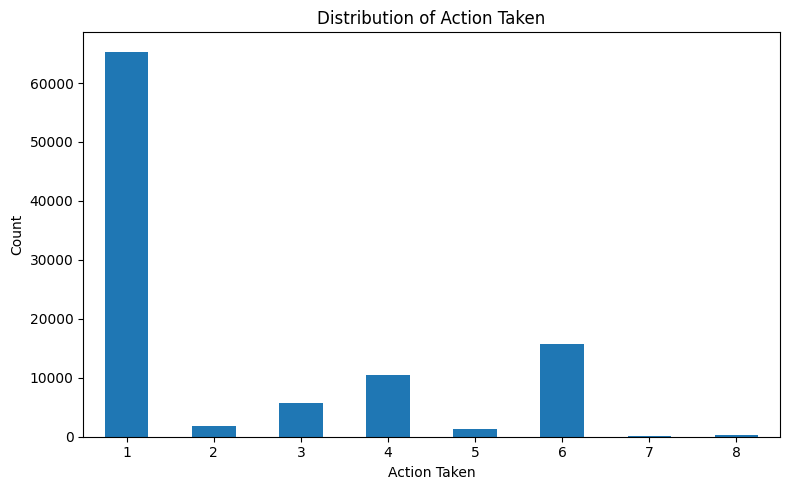

In [15]:
action_counts = df["action_taken"].value_counts().sort_index()

plt.figure(figsize=(8,5))
action_counts.plot(kind="bar")
plt.title("Distribution of Action Taken")
plt.xlabel("Action Taken")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
df['loan_amount'].value_counts()

,count
loan_amount,
15000.0,3841
245000.0,3119
255000.0,3107
265000.0,2993
305000.0,2991
...,...
6965000.0,1
54175000.0,1
19005000.0,1


In [17]:
df['property_value'].value_counts()

,count
property_value,
255000.0,2527
275000.0,2499
285000.0,2498
265000.0,2440
325000.0,2428
...,...
82475000.0,1
5405000.0,1
30425000.0,1


In [18]:
df['income'].value_counts()

,count
income,
80.0,1017
60.0,1016
70.0,958
75.0,951
90.0,915
...,...
1470.0,1
1047.0,1
1471.0,1


In [19]:
df['interest_rate'].value_counts()

,count
interest_rate,
6.625,5131
6.500,4921
6.750,4699
6.875,4568
7.125,3904
...,...
7.820,1
4.825,1
5.025,1


In [20]:
df['tract_minority_population_percent'].value_counts()

,count
tract_minority_population_percent,
0.00,1016
20.69,649
27.78,580
10.98,573
14.61,441
...,...
83.09,6
27.64,5
43.94,4


In [21]:
df['tract_to_msa_income_percentage'].value_counts()

,count
tract_to_msa_income_percentage,
0.00,1162
121.35,606
156.68,580
95.42,561
104.59,441
...,...
113.97,6
30.25,6
33.47,3


In [22]:
df['denial_reason-1'].value_counts()

,count
denial_reason-1,
10,91544
1111,3576
1,2231
3,1204
4,773
9,471
7,401
5,279
6,271


In [23]:
df['covenant_count'].value_counts()

,count
covenant_count,
0.0,89762
1.0,684
3.0,532
2.0,488
212.0,294
...,...
176.0,29
15.0,28
126.0,27


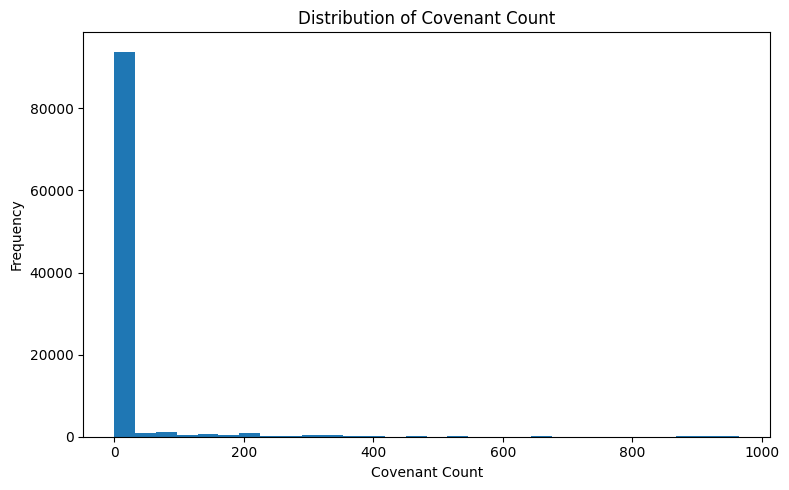

In [24]:
plt.figure(figsize=(8,5))
df["covenant_count"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Covenant Count")
plt.xlabel("Covenant Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [25]:
df['was_approved'].value_counts()



,count
was_approved,
True,67085
False,33846


In [26]:
df['covenant_density'].value_counts()

,count
covenant_density,
Low (1-50),4537
Very High (>200),3140
Medium (51-100),1772
High (101-200),1720


In [27]:
# Median values by race
race_summary = df.groupby("derived_race")[[
    "income",
    "property_value",
    "loan_amount",
    "tract_minority_population_percent",
    "tract_to_msa_income_percentage",
    "covenant_count"
]].median()

print(race_summary)

                                           income  property_value  \
derived_race                                                        
2 or more minority races                     83.0        295000.0   
American Indian or Alaska Native             76.0        265000.0   
Asian                                       102.0        355000.0   
Black or African American                    87.0        335000.0   
Free Form Text Only                         109.0        385000.0   
Joint                                       122.0        355000.0   
Native Hawaiian or Other Pacific Islander    64.5        255000.0   
Race Not Available                           95.0        335000.0   
White                                        96.0        315000.0   

                                           loan_amount  \
derived_race                                             
2 or more minority races                      255000.0   
American Indian or Alaska Native              215000.0   
Asian   

In [28]:
# Approval rate by race
race_approval = df.groupby("derived_race")["was_approved"].agg(["count", "mean"])
race_approval["approval_rate_percent"] = (race_approval["mean"] * 100).round(2)

print(race_approval[["count", "approval_rate_percent"]].sort_values(by="approval_rate_percent", ascending=False))

                                           count  approval_rate_percent
derived_race                                                           
Free Form Text Only                            5                  80.00
White                                      63627                  75.61
Joint                                       2427                  74.41
Asian                                       5905                  70.77
2 or more minority races                     135                  65.93
American Indian or Alaska Native             709                  62.20
Black or African American                   5199                  60.42
Native Hawaiian or Other Pacific Islander    113                  56.64
Race Not Available                         22811                  40.57


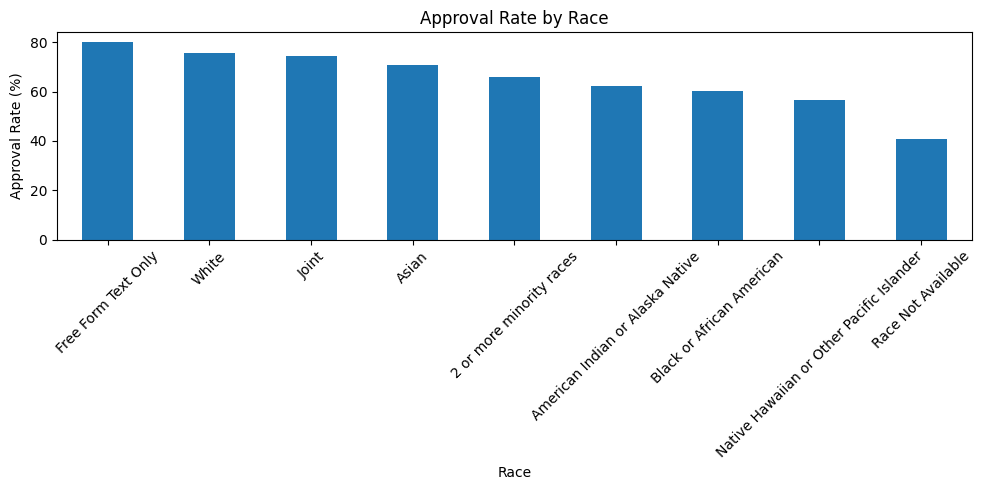

In [29]:
approval_plot = race_approval["approval_rate_percent"].sort_values(ascending=False)

plt.figure(figsize=(10,5))
approval_plot.plot(kind="bar")
plt.title("Approval Rate by Race")
plt.xlabel("Race")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Data Bias

In [30]:
# Create covenant variables
df["covenant_binary"] = np.where(
    df["covenant_count"].fillna(0) > 0,
    "Covenanted",
    "Non-Covenanted"
)

bins = [-1, 0, 50, 100, 200, np.inf]
labels = ["0", "1-50", "51-100", "101-200", ">200"]

df["covenant_group"] = pd.cut(
    df["covenant_count"].fillna(0),
    bins=bins,
    labels=labels
)

In [31]:
app = df[df["action_taken"].isin([1, 2, 3, 7, 8])].copy()
app["approved_clean"] = app["action_taken"].isin([1, 2, 8])

app["covenant_group"] = pd.cut(
    app["covenant_count"].fillna(0),
    bins=bins,
    labels=labels
)


Median property value by covenant group:
covenant_group
0          315000.0
1-50       325000.0
51-100     365000.0
101-200    375000.0
>200       385000.0
Name: property_value, dtype: float64


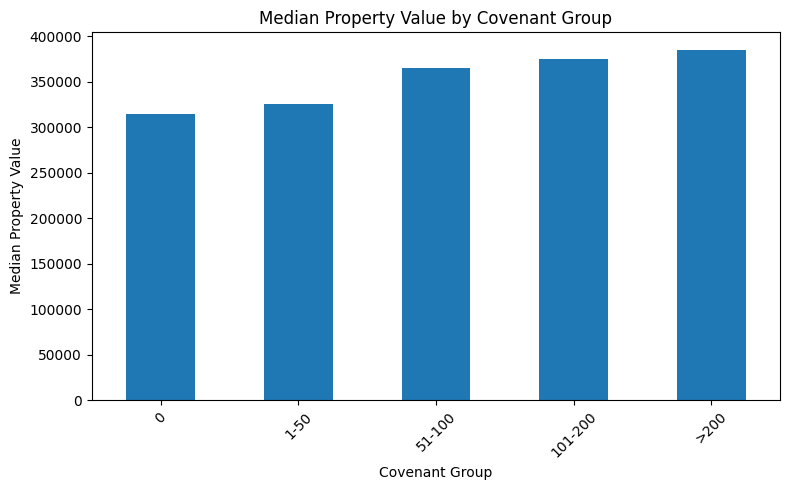

In [32]:
#  Property value by covenant group
property_by_covenant = df.groupby("covenant_group", observed=False)["property_value"].median()
print("\nMedian property value by covenant group:")
print(property_by_covenant)

plt.figure(figsize=(8, 5))
property_by_covenant.plot(kind="bar")
plt.title("Median Property Value by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Median Property Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Property / neighborhood summary by covenant status:
                 median_property_value  mean_property_value  median_income  \
covenant_binary                                                              
Covenanted                    355000.0        487349.429698          111.0   
Non-Covenanted                315000.0        387560.383214           94.0   

                 avg_minority_pct  avg_tract_msa_income  
covenant_binary                                          
Covenanted              30.374508            110.928425  
Non-Covenanted          21.940751            100.679432  


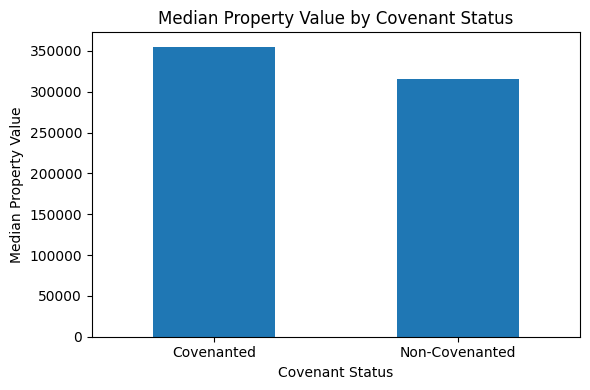

In [33]:
#  Property / neighborhood summary by covenant status
property_binary = df.groupby("covenant_binary").agg(
    median_property_value=("property_value", "median"),
    mean_property_value=("property_value", "mean"),
    median_income=("income", "median"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_msa_income=("tract_to_msa_income_percentage", "mean")
)

print("\nProperty / neighborhood summary by covenant status:")
print(property_binary)

# graph for median property value by covenant status
plt.figure(figsize=(6, 4))
property_binary["median_property_value"].plot(kind="bar")
plt.title("Median Property Value by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Median Property Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

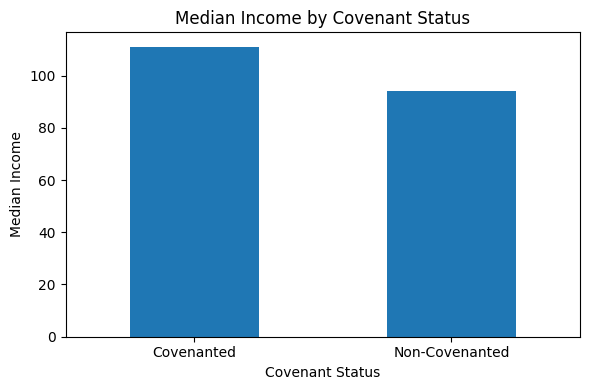

In [34]:
# graph for median income by covenant status
plt.figure(figsize=(6, 4))
property_binary["median_income"].plot(kind="bar")
plt.title("Median Income by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Median Income")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Approval patterns by covenant status:
                 applications  approval_rate  denial_rate  median_income  \
covenant_binary                                                            
Covenanted               7929       0.948039     0.051961          113.0   
Non-Covenanted          65487       0.915342     0.084658           96.0   

                 median_property_value  
covenant_binary                         
Covenanted                    365000.0  
Non-Covenanted                325000.0  


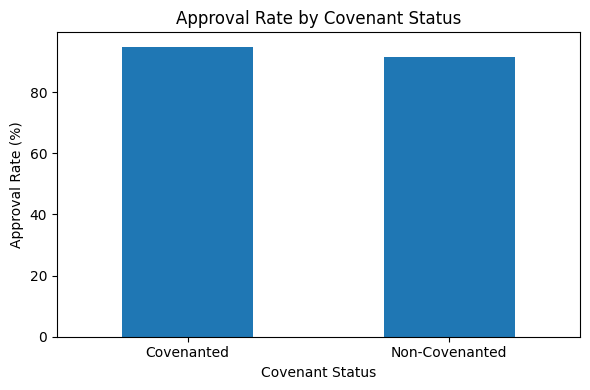

In [35]:
#Approval patterns by covenant status
approval_by_area = app.groupby("covenant_binary").agg(
    applications=("approved_clean", "size"),
    approval_rate=("approved_clean", "mean"),
    denial_rate=("approved_clean", lambda x: 1 - x.mean()),
    median_income=("income", "median"),
    median_property_value=("property_value", "median")
)

print("\nApproval patterns by covenant status:")
print(approval_by_area)

plt.figure(figsize=(6, 4))
(approval_by_area["approval_rate"] * 100).plot(kind="bar")
plt.title("Approval Rate by Covenant Status")
plt.xlabel("Covenant Status")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Approval patterns by race:
                                           applications  approval_rate  \
derived_race                                                             
Joint                                              1939       0.933471   
White                                             51975       0.930909   
Asian                                              4557       0.918806   
Race Not Available                                10460       0.889866   
2 or more minority races                            103       0.873786   
Black or African American                          3751       0.844042   
American Indian or Alaska Native                    539       0.827458   
Free Form Text Only                                   5       0.800000   
Native Hawaiian or Other Pacific Islander            87       0.747126   

                                           denial_rate  median_income  \
derived_race                                                            
Joint      

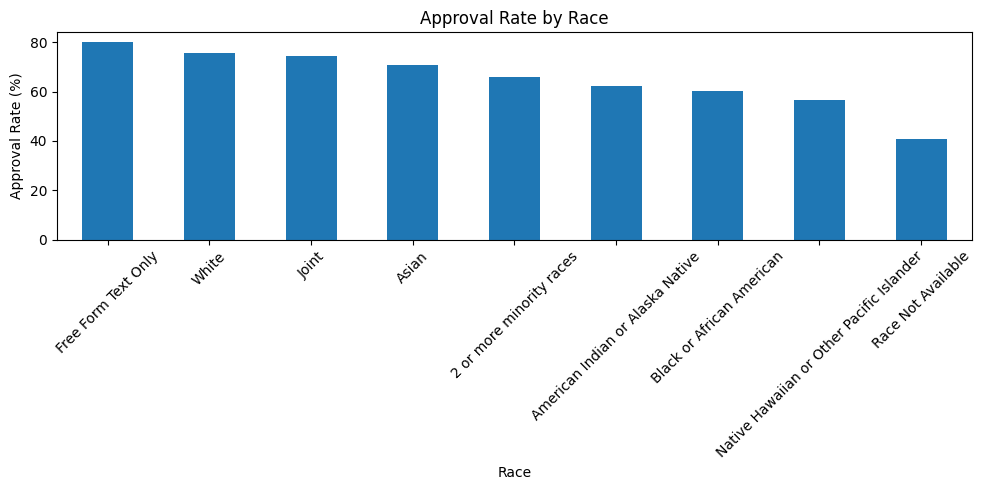

In [36]:
# Approval patterns by race
approval_by_race = app.groupby("derived_race").agg(
    applications=("approved_clean", "size"),
    approval_rate=("approved_clean", "mean"),
    denial_rate=("approved_clean", lambda x: 1 - x.mean()),
    median_income=("income", "median"),
    median_property_value=("property_value", "median"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_msa_income=("tract_to_msa_income_percentage", "mean")
).sort_values("approval_rate", ascending=False)

print("\nApproval patterns by race:")
print(approval_by_race)

plt.figure(figsize=(10,5))
approval_plot.plot(kind="bar")
plt.title("Approval Rate by Race")
plt.xlabel("Race")
plt.ylabel("Approval Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


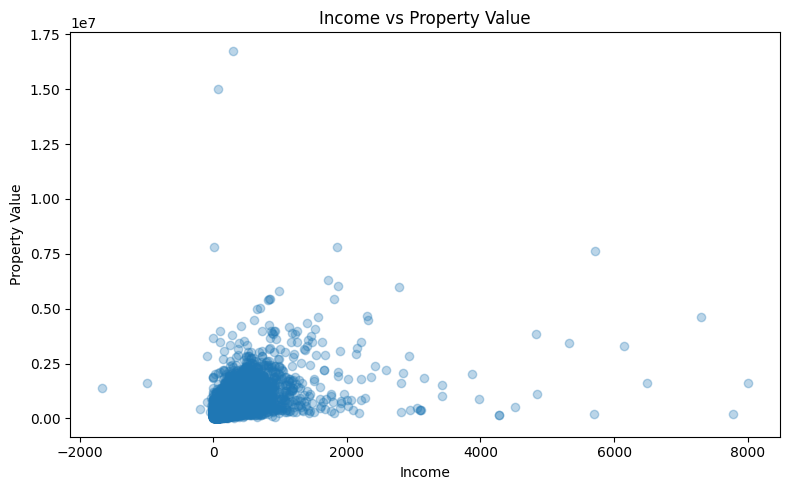

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(df["income"], df["property_value"], alpha=0.3)
plt.title("Income vs Property Value")
plt.xlabel("Income")
plt.ylabel("Property Value")
plt.tight_layout()
plt.show()

In [38]:
neighborhood_summary = df.groupby("covenant_group").agg(
    avg_income=("income", "mean"),
    avg_property_value=("property_value", "mean"),
    avg_minority_pct=("tract_minority_population_percent", "mean"),
    avg_tract_income=("tract_to_msa_income_percentage", "mean")
)

print("\nNeighborhood Differences by Covenant Group:")
print(neighborhood_summary)


Neighborhood Differences by Covenant Group:
                avg_income  avg_property_value  avg_minority_pct  \
covenant_group                                                     
0               147.222444       387560.383214         21.940751   
1-50            139.971892       418831.701508         37.501120   
51-100          168.160550       567187.500000         26.929069   
101-200         181.273954       547739.916551         24.150360   
>200            184.480253       506902.255639         25.431010   

                avg_tract_income  
covenant_group                    
0                     100.679432  
1-50                   99.387064  
51-100                112.761580  
101-200               116.914163  
>200                  123.291271  


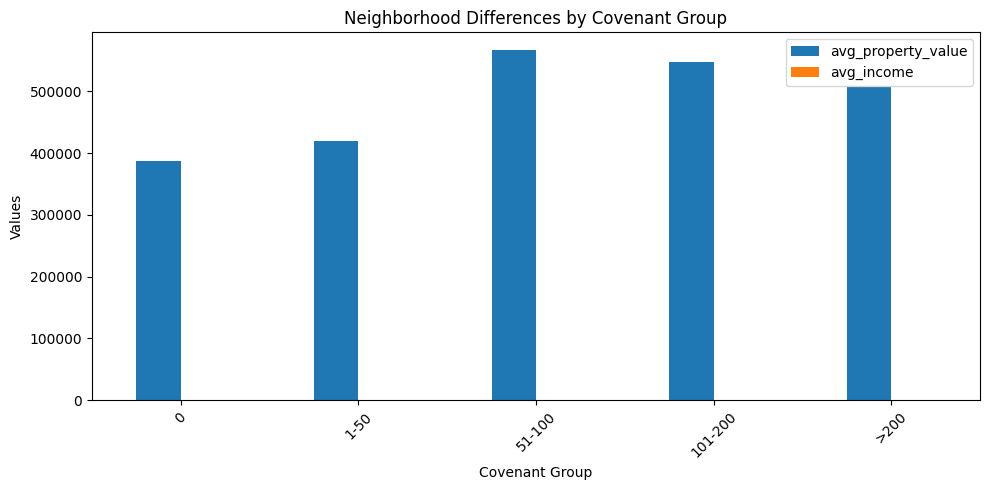

In [39]:
neighborhood_summary[["avg_property_value", "avg_income"]].plot(kind="bar", figsize=(10,5))
plt.title("Neighborhood Differences by Covenant Group")
plt.xlabel("Covenant Group")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Algorithmic Bias Analysis

### 1. Prepare Features for Modeling

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

# Drop interest_rate — it's mostly missing for denied loans, which wipes out the denial class
model_features = [
    "income",
    "loan_amount",
    "property_value",
    "tract_to_msa_income_percentage",
    "tract_minority_population_percent",
    "covenant_count"
]

model_df = app[model_features + ["action_taken"]].copy()
model_df["covenant_count"] = model_df["covenant_count"].fillna(0)
model_df["approved"] = model_df["action_taken"].isin([1, 2, 8]).astype(int)
model_df = model_df.drop(columns=["action_taken"]).dropna()

X = model_df[model_features]
y = model_df["approved"]

print(f"Modeling dataset: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"Approved: {y.sum():,} ({y.mean():.1%})  |  Denied: {(1-y).sum():,} ({(1-y).mean():.1%})")
assert y.nunique() == 2, f"Still only one class: {y.unique()} — check action_taken values"

Modeling dataset: 66,588 rows, 6 features
Approved: 61,344 (92.1%)  |  Denied: 5,244 (7.9%)


### 2. Train Logistic Regression Model

=== Classification Report ===
              precision    recall  f1-score   support

      Denied       1.00      0.00      0.00      1049
    Approved       0.92      1.00      0.96     12269

    accuracy                           0.92     13318
   macro avg       0.96      0.50      0.48     13318
weighted avg       0.93      0.92      0.88     13318



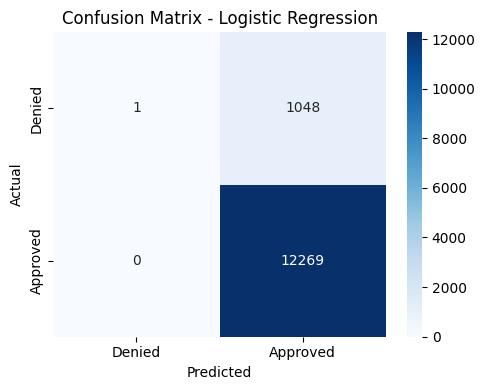

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Denied", "Approved"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Denied","Approved"],
            yticklabels=["Denied","Approved"], ax=ax)
ax.set_title("Confusion Matrix - Logistic Regression")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()


### 3. Feature Importance - Proxy Variable Analysis

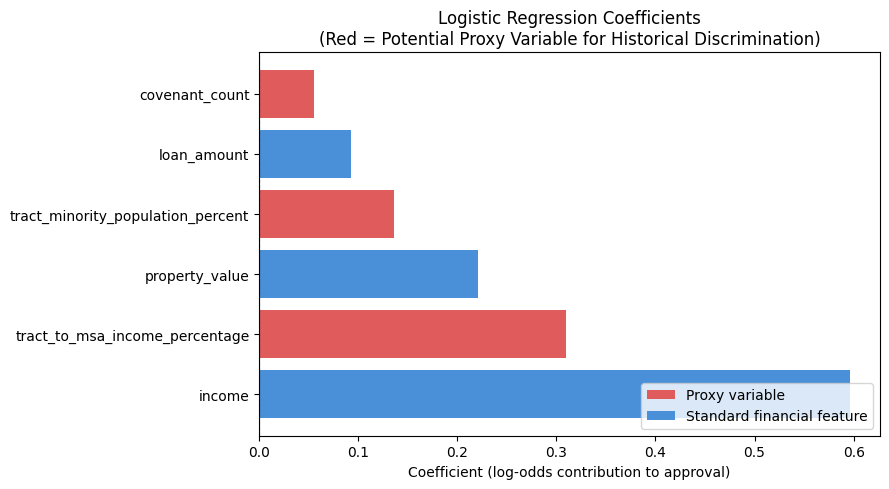


Coefficient Table:
                          feature  coefficient  is_proxy
                           income     0.596755     False
   tract_to_msa_income_percentage     0.309216      True
                   property_value     0.220745     False
tract_minority_population_percent     0.136440      True
                      loan_amount     0.092403     False
                   covenant_count     0.055872      True


In [44]:
coef_df = pd.DataFrame({
    "feature": model_features,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)

proxy_vars = [
    "tract_minority_population_percent",
    "covenant_count",
    "tract_to_msa_income_percentage"
]
coef_df["is_proxy"] = coef_df["feature"].isin(proxy_vars)
colors = ["#e05c5c" if p else "#4a90d9" for p in coef_df["is_proxy"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Logistic Regression Coefficients\n"
             "(Red = Potential Proxy Variable for Historical Discrimination)")
ax.set_xlabel("Coefficient (log-odds contribution to approval)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#e05c5c", label="Proxy variable"),
    Patch(facecolor="#4a90d9", label="Standard financial feature")
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

print("\nCoefficient Table:")
print(coef_df.to_string(index=False))


### 4. Disparate Impact Analysis

Baseline approval rate (White): 93.1%

Disparate Impact by Race:
                             derived_race  approval_rate_pct  disparate_impact_ratio  passes_80pct_rule
                                    Joint              93.35                  1.0028               True
                                    White              93.09                  1.0000               True
                                    Asian              91.88                  0.9870               True
                       Race Not Available              88.99                  0.9559               True
                 2 or more minority races              87.38                  0.9386               True
                Black or African American              84.40                  0.9067               True
         American Indian or Alaska Native              82.75                  0.8889               True
                      Free Form Text Only              80.00                  0.8594               True

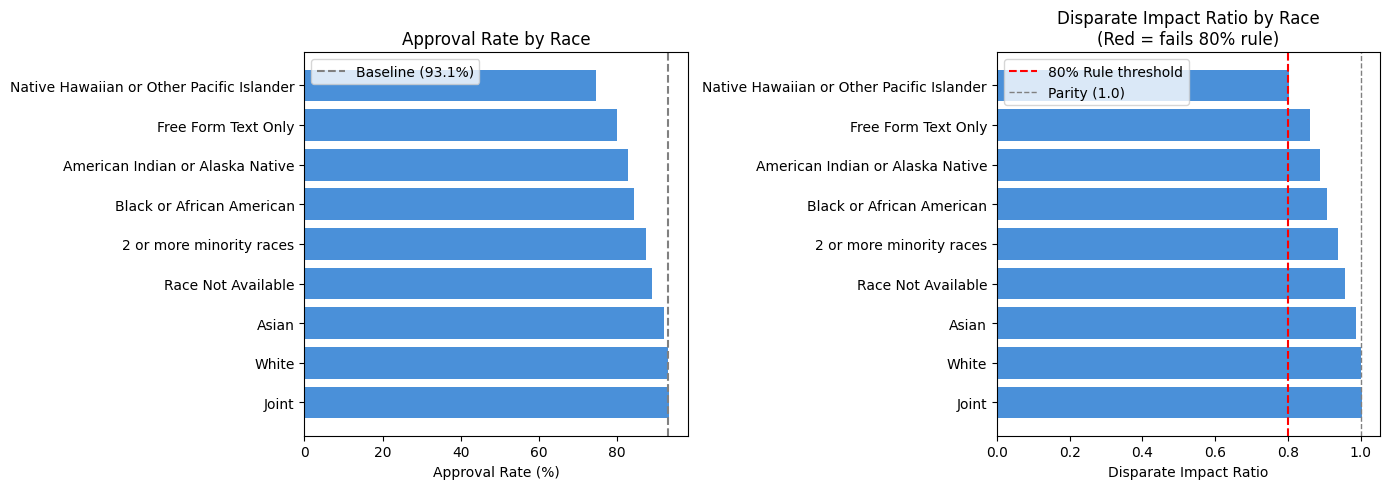

In [45]:
# Rebuild app2 with a clean approved column from action_taken
app2 = app.copy()
app2["covenant_count"] = app2["covenant_count"].fillna(0)
app2["approved"] = app2["action_taken"].isin([1, 2, 8]).astype(int)

# Approval rate by race
di_race = (app2.groupby("derived_race")["approved"]
           .mean()
           .rename("approval_rate")
           .reset_index()
           .sort_values("approval_rate", ascending=False))

# Use White as baseline (EEOC 80% / four-fifths rule)
baseline_rate = di_race.loc[di_race["derived_race"] == "White", "approval_rate"].values
if len(baseline_rate) == 0:
    baseline_rate = di_race["approval_rate"].max()
    print("White not found; using highest approval group as baseline.")
else:
    baseline_rate = baseline_rate[0]

di_race["disparate_impact_ratio"] = (di_race["approval_rate"] / baseline_rate).round(4)
di_race["passes_80pct_rule"] = di_race["disparate_impact_ratio"] >= 0.80
di_race["approval_rate_pct"] = (di_race["approval_rate"] * 100).round(2)

print(f"Baseline approval rate (White): {baseline_rate:.1%}")
print("\nDisparate Impact by Race:")
print(di_race[["derived_race","approval_rate_pct","disparate_impact_ratio","passes_80pct_rule"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ["#e05c5c" if not p else "#4a90d9" for p in di_race["passes_80pct_rule"]]
axes[0].barh(di_race["derived_race"], di_race["approval_rate_pct"], color=colors_bar)
axes[0].axvline(baseline_rate * 100, color="gray", linestyle="--",
                label=f"Baseline ({baseline_rate:.1%})")
axes[0].set_title("Approval Rate by Race")
axes[0].set_xlabel("Approval Rate (%)")
axes[0].legend()

axes[1].barh(di_race["derived_race"], di_race["disparate_impact_ratio"], color=colors_bar)
axes[1].axvline(0.80, color="red", linestyle="--", linewidth=1.5, label="80% Rule threshold")
axes[1].axvline(1.0,  color="gray", linestyle="--", linewidth=1, label="Parity (1.0)")
axes[1].set_title("Disparate Impact Ratio by Race\n(Red = fails 80% rule)")
axes[1].set_xlabel("Disparate Impact Ratio")
axes[1].legend()

plt.tight_layout()
plt.show()


### 5. Denial Reasons by Race

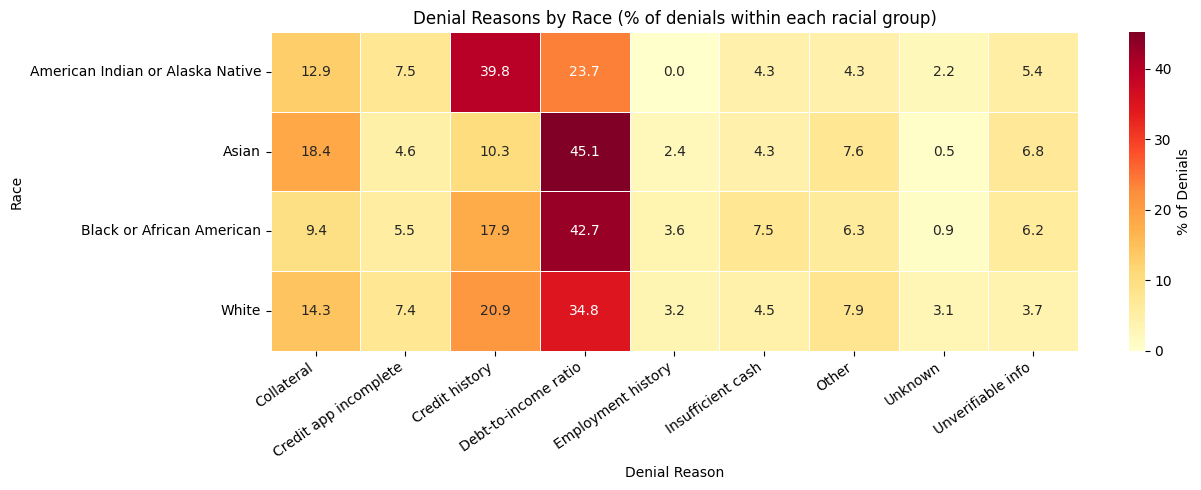


Top Denial Reason per Race:
                            Race    Top Denial Reason  Pct of Denials
American Indian or Alaska Native       Credit history            39.8
                           Asian Debt-to-income ratio            45.1
       Black or African American Debt-to-income ratio            42.7
                           White Debt-to-income ratio            34.8


In [46]:
denial_labels = {
    1: "Debt-to-income ratio",
    2: "Employment history",
    3: "Credit history",
    4: "Collateral",
    5: "Insufficient cash",
    6: "Unverifiable info",
    7: "Credit app incomplete",
    8: "Mortgage insurance denied",
    9: "Other",
    10: "N/A"
}

denied = app2[app2["approved"] == 0].copy()
denied["denial_reason_label"] = denied["denial_reason-1"].map(denial_labels).fillna("Unknown")

major_races = [
    "White", "Black or African American", "Asian",
    "Hispanic or Latino", "American Indian or Alaska Native"
]
denied_major = denied[denied["derived_race"].isin(major_races)]

denial_crosstab = (
    denied_major.groupby(["derived_race", "denial_reason_label"])
    .size()
    .reset_index(name="count")
)
denial_crosstab["pct"] = (
    denial_crosstab.groupby("derived_race")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

pivot = denial_crosstab.pivot(
    index="derived_race", columns="denial_reason_label", values="pct"
).fillna(0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.4, cbar_kws={"label": "% of Denials"})
ax.set_title("Denial Reasons by Race (% of denials within each racial group)")
ax.set_xlabel("Denial Reason")
ax.set_ylabel("Race")
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

top_denial = (
    denial_crosstab.sort_values("pct", ascending=False)
    .groupby("derived_race").first()
    .reset_index()
    [["derived_race","denial_reason_label","pct"]]
)
top_denial.columns = ["Race","Top Denial Reason","Pct of Denials"]
top_denial["Pct of Denials"] = top_denial["Pct of Denials"].round(1)
print("\nTop Denial Reason per Race:")
print(top_denial.to_string(index=False))


### 6. Loan Terms - Interest Rate Disparities by Race & Covenant Status

Approved loans with valid interest rate: 61,038


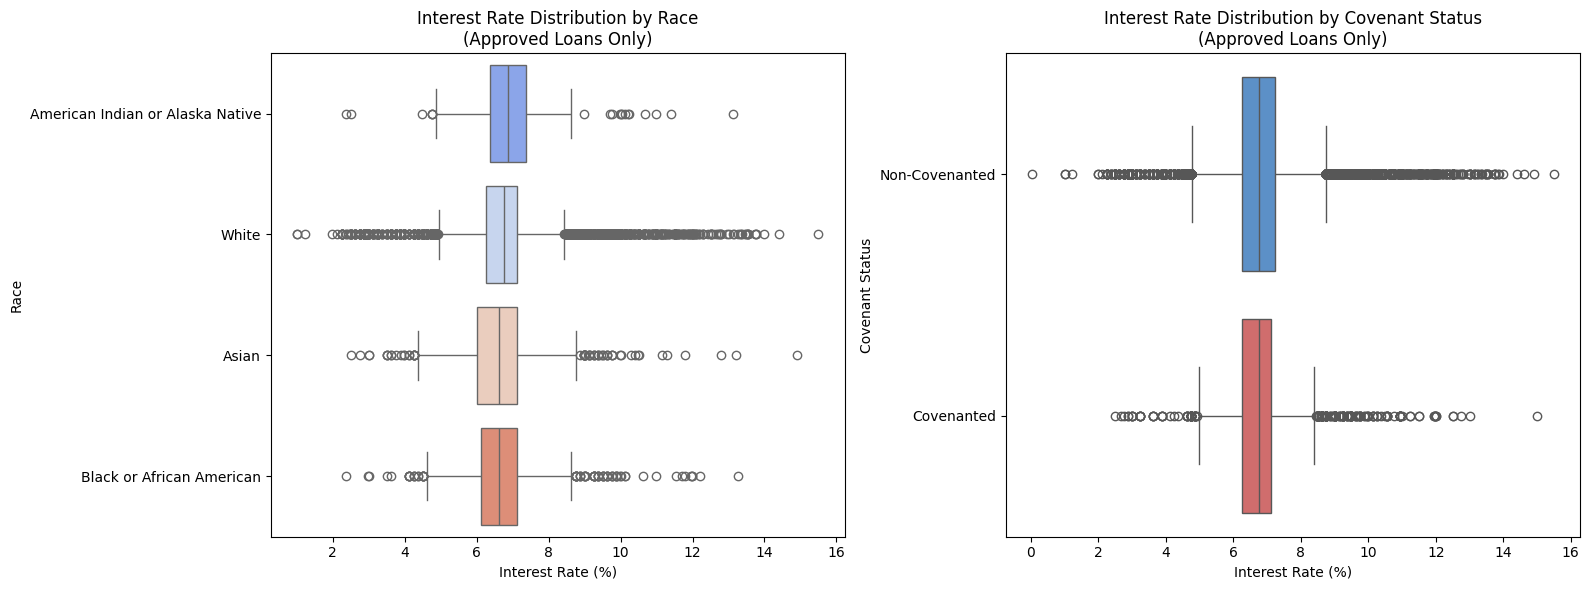


Median Interest Rate by Race (Approved Loans):
                                  median   mean    std  count
derived_race                                                 
American Indian or Alaska Native   6.875  6.904  1.012    397
White                              6.750  6.718  0.839  44456
Asian                              6.625  6.602  0.892   3991
Black or African American          6.625  6.631  0.878   2940

Median Interest Rate by Covenant Status (Approved Loans):
                 median   mean    std  count
covenant_binary                             
Covenanted         6.75  6.752  0.821   6957
Non-Covenanted     6.75  6.725  0.898  54081

Welch t-test: Covenanted vs Non-Covenanted interest rates
  t = 2.5326,  p = 0.0113
  Result: Statistically significant (p<0.05) -- covenanted-area loans have lower rates.


In [47]:
approved_loans = app2[
    (app2["approved"] == 1) &
    (app2["interest_rate"].notna()) &
    (app2["interest_rate"] > 0) &
    (app2["interest_rate"] < 30)
].copy()

print(f"Approved loans with valid interest rate: {len(approved_loans):,}")

approved_major = approved_loans[approved_loans['derived_race'].isin(major_races)]
race_order = (
    approved_major.groupby('derived_race')['interest_rate']
    .median().sort_values(ascending=False).index.tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=approved_major, x='interest_rate', y='derived_race',
            order=race_order, palette='coolwarm', ax=axes[0])
axes[0].set_title("Interest Rate Distribution by Race\n(Approved Loans Only)")
axes[0].set_xlabel("Interest Rate (%)")
axes[0].set_ylabel("Race")

sns.boxplot(data=approved_loans, x='interest_rate', y='covenant_binary',
            palette={'Covenanted': '#e05c5c', 'Non-Covenanted': '#4a90d9'},
            ax=axes[1])
axes[1].set_title("Interest Rate Distribution by Covenant Status\n(Approved Loans Only)")
axes[1].set_xlabel("Interest Rate (%)")
axes[1].set_ylabel("Covenant Status")

plt.tight_layout()
plt.show()

rate_by_race = (
    approved_major.groupby('derived_race')['interest_rate']
    .agg(median='median', mean='mean', std='std', count='count')
    .round(3).sort_values('median', ascending=False)
)
rate_by_covenant = (
    approved_loans.groupby('covenant_binary')['interest_rate']
    .agg(median='median', mean='mean', std='std', count='count')
    .round(3).sort_values('median', ascending=False)
)

print("\nMedian Interest Rate by Race (Approved Loans):")
print(rate_by_race.to_string())

print("\nMedian Interest Rate by Covenant Status (Approved Loans):")
print(rate_by_covenant.to_string())

cov_rates    = approved_loans[approved_loans['covenant_binary']=='Covenanted']['interest_rate'].dropna()
noncov_rates = approved_loans[approved_loans['covenant_binary']=='Non-Covenanted']['interest_rate'].dropna()

if len(cov_rates) > 1 and len(noncov_rates) > 1:
    t_stat, p_val = stats.ttest_ind(cov_rates, noncov_rates, equal_var=False)
    print(f"\nWelch t-test: Covenanted vs Non-Covenanted interest rates")
    print(f"  t = {t_stat:.4f},  p = {p_val:.4f}")
    if p_val < 0.05:
        direction = 'higher' if cov_rates.median() > noncov_rates.median() else 'lower'
        print(f"  Result: Statistically significant (p<0.05) -- covenanted-area loans have {direction} rates.")
    else:
        print("  Result: Difference is NOT statistically significant at p<0.05.")
else:
    print("Not enough data in one group for t-test.")
